In [ ]:
import numpy as np
import plotly.graph_objects as go
import importlib
import matplotlib.pyplot as plt

import pyerti
pyerti = importlib.reload(pyerti)
from utils.crb_utils import (
    SimulationConfig,
    finite_difference_jacobian_range_angle,
    fisher_poisson,
    make_parametric_facet_object_positions,
)

# Parametros nominales de la simulacion. Ajusta estos valores si quieres validar
# otro punto del espacio de parametros.
rho = 2
phi_deg = 150.0
height = 1.5
facet_width = 0.4
range_step = 0.01
angle_step_deg = 0.05

rho0 = rho
phi0 = np.deg2rad(phi_deg)
h0 = height

config = SimulationConfig(camera_FOV=0.5, cam_pixel_dim=64)
# False muestra paredes/techo en la escena; True acelera la simulacion mostrando solo el facet.
scene_hide_walls = True

psi0 = np.array([rho0, phi0, h0], dtype=float)
steps = np.array([range_step, np.deg2rad(angle_step_deg), 0.01], dtype=float)


In [ ]:
object_positions = make_parametric_facet_object_positions(
    rho=rho,
    phi=np.deg2rad(phi_deg),
    h=height,
    width=facet_width,
)

fig3d, transient, sim_params = pyerti.simulation(
    **config.kwargs(),
    object_positions=object_positions,
    hide_walls=scene_hide_walls,
)

fig3d.update_layout(title="Escena 3D nominal")
fig3d.show()

y_sum = transient.sum(axis=2)
columns_rolled_in_simulation = sim_params.get("columns_rolled", False)
transient_collapsed = y_sum if columns_rolled_in_simulation else np.roll(y_sum, shift=1, axis=-1)
fig_transient = go.Figure(
    data=go.Heatmap(
        z=transient_collapsed,
        colorscale="Viridis",
        colorbar=dict(title="intensidad"),
    )
)
fig_transient.update_layout(
    title="Transient colapsado temporalmente, columnas corregidas",
    xaxis_title="pixel x",
    yaxis_title="pixel y",
    width=650,
    height=600,
)
fig_transient.update_yaxes(scaleanchor="x", autorange="reversed")
fig_transient.show()

print("transient shape:", transient.shape)
print("num time bins:", sim_params["num_time_bins"])
print("columns rolled in simulation:", columns_rolled_in_simulation)
print("collapsed min/max:", transient_collapsed.min(), transient_collapsed.max())


transient shape: (64, 64, 97)
num time bins: 97
columns rolled in simulation: True
collapsed min/max: 0.05807498428462656 1.5415582314486251


In [35]:
g0, jacobian = finite_difference_jacobian_range_angle(
    psi0=psi0,
    steps=steps,
    config=config,
    width=facet_width,
)
FIM = fisher_poisson(g0, jacobian)
J = jacobian
I = FIM
CRB = np.linalg.pinv(FIM)
image_shape = (config.cam_pixel_dim, config.cam_pixel_dim, -1)
range_image = np.abs(jacobian[:, 0]).reshape(image_shape).sum(axis=2)
angle_image = np.abs(jacobian[:, 1]).reshape(image_shape).sum(axis=2)

print("FIM shape:", FIM.shape)
print("CRB shape:", CRB.shape)
print("range_image shape:", range_image.shape)
print("angle_image shape:", angle_image.shape)
print(CRB)


FIM shape: (2, 2)
CRB shape: (2, 2)
range_image shape: (64, 64)
angle_image shape: (64, 64)
[[ 3.38782222e-10 -5.53413191e-11]
 [-5.53413191e-11  1.19904076e-03]]


angle_step_deg | ||dg/drho|| | ||dg/dphi|| | sigma_rho [m] | sigma_phi [rad] | rho*sigma_phi [m] | corr | cond(FIM)
             1 |  2.0936e+00 |  1.0270e+00 |    1.8406e-05 |      1.3219e-05 |        2.6438e-05 | -0.0000 | 1.9388e+00
           0.5 |  2.0936e+00 |  1.0461e+00 |    1.8406e-05 |      1.6336e-05 |        3.2673e-05 | -0.0000 | 1.2694e+00
          0.25 |  2.0936e+00 |  1.0615e+00 |    1.8406e-05 |      2.7752e-05 |        5.5505e-05 | -0.0000 | 2.2734e+00
           0.1 |  2.0936e+00 |  1.0902e+00 |    1.8406e-05 |      3.3558e-05 |        6.7115e-05 | -0.0000 | 3.3240e+00
          0.05 |  2.0936e+00 |  1.1343e+00 |    1.8406e-05 |      3.4627e-02 |        6.9254e-02 | -0.0001 | 3.5393e+06
          0.01 |  2.0936e+00 |  2.5516e+00 |    1.8406e-05 |      1.7745e-02 |        3.5490e-02 | -0.0001 | 9.2948e+05
         0.005 |  2.0936e+00 |  2.9209e+00 |    1.8406e-05 |      1.6554e-02 |        3.3108e-02 | -0.0000 | 8.0888e+05
         0.001 |  2.0936e+00 |  5.7883e+00 |

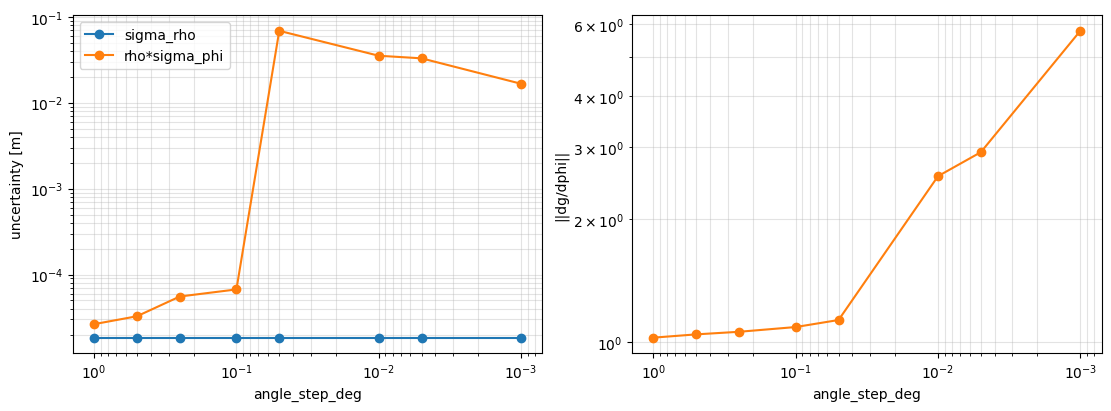

In [36]:
angle_step_test_deg = np.array([1.0, 0.5, 0.25, 0.1, 0.05, 0.01, 0.005, 0.001], dtype=float)
step_test_rows = []

for test_angle_step_deg in angle_step_test_deg:
    test_steps = np.array([range_step, np.deg2rad(test_angle_step_deg), 0.01], dtype=float)
    test_g0, test_J = finite_difference_jacobian_range_angle(
        psi0=psi0,
        steps=test_steps,
        config=config,
        width=facet_width,
    )
    test_I = fisher_poisson(test_g0, test_J)
    test_CRB = np.linalg.pinv(test_I)
    test_sigma_rho = np.sqrt(max(test_CRB[0, 0], 0.0))
    test_sigma_phi = np.sqrt(max(test_CRB[1, 1], 0.0))
    test_corr = test_CRB[0, 1] / np.sqrt(test_CRB[0, 0] * test_CRB[1, 1])
    step_test_rows.append({
        "angle_step_deg": test_angle_step_deg,
        "norm_dg_drho": np.linalg.norm(test_J[:, 0]),
        "norm_dg_dphi": np.linalg.norm(test_J[:, 1]),
        "sigma_rho_m": test_sigma_rho,
        "sigma_phi_rad": test_sigma_phi,
        "rho_sigma_phi_m": rho0 * test_sigma_phi,
        "corr": test_corr,
        "cond_FIM": np.linalg.cond(test_I),
    })

print("angle_step_deg | ||dg/drho|| | ||dg/dphi|| | sigma_rho [m] | sigma_phi [rad] | rho*sigma_phi [m] | corr | cond(FIM)")
for row in step_test_rows:
    print(
        f"{row['angle_step_deg']:>14.6g} | "
        f"{row['norm_dg_drho']:>11.4e} | "
        f"{row['norm_dg_dphi']:>11.4e} | "
        f"{row['sigma_rho_m']:>13.4e} | "
        f"{row['sigma_phi_rad']:>15.4e} | "
        f"{row['rho_sigma_phi_m']:>17.4e} | "
        f"{row['corr']:> .4f} | "
        f"{row['cond_FIM']:>9.4e}"
    )

angle_steps = np.array([row["angle_step_deg"] for row in step_test_rows])
sigma_rhos = np.array([row["sigma_rho_m"] for row in step_test_rows])
rho_sigma_phis = np.array([row["rho_sigma_phi_m"] for row in step_test_rows])
norm_dphis = np.array([row["norm_dg_dphi"] for row in step_test_rows])

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].loglog(angle_steps, sigma_rhos, "o-", label="sigma_rho")
axes[0].loglog(angle_steps, rho_sigma_phis, "o-", label="rho*sigma_phi")
axes[0].invert_xaxis()
axes[0].set_xlabel("angle_step_deg")
axes[0].set_ylabel("uncertainty [m]")
axes[0].grid(True, which="both", alpha=0.35)
axes[0].legend()

axes[1].loglog(angle_steps, norm_dphis, "o-", color="tab:orange")
axes[1].invert_xaxis()
axes[1].set_xlabel("angle_step_deg")
axes[1].set_ylabel("||dg/dphi||")
axes[1].grid(True, which="both", alpha=0.35)


In [37]:
Sigma = CRB[np.ix_([0, 1], [0, 1])]

eigvals, eigvecs = np.linalg.eigh(Sigma)

print("CRB rho-rho:", CRB[0, 0])
print("CRB phi-phi:", CRB[1, 1])
print("CRB rho-phi:", CRB[0, 1])
print("eigenvalues:", eigvals)
print("sqrt eigenvalues:", np.sqrt(np.maximum(eigvals, 0)))
print("anisotropy ratio:", np.sqrt(eigvals.max() / eigvals.min()))
print("eigenvectors:")
print(eigvecs)

CRB rho-rho: 3.387822219357226e-10
CRB phi-phi: 0.0011990407606682556
CRB rho-phi: -5.534131912535365e-11
eigenvalues: [3.38782219e-10 1.19904076e-03]
sqrt eigenvalues: [1.84060376e-05 3.46271680e-02]
anisotropy ratio: 1881.2939942384837
eigenvectors:
[[-1.00000000e+00 -4.61546734e-08]
 [-4.61546734e-08  1.00000000e+00]]


In [38]:
print("||dg/drho||:", np.linalg.norm(J[:, 0]))
print("||dg/dphi||:", np.linalg.norm(J[:, 1]))
print("I:")
print(I)
print("CRB:")
print(CRB)

||dg/drho||: 2.0936342291907875
||dg/dphi||: 1.1343156490567377
I:
[[2.95174877e+09 1.36236962e+02]
 [1.36236962e+02 8.34000011e+02]]
CRB:
[[ 3.38782222e-10 -5.53413191e-11]
 [-5.53413191e-11  1.19904076e-03]]


In [39]:
sigma_rho = np.sqrt(CRB[0, 0])
sigma_phi = np.sqrt(CRB[1, 1])
sigma_tangential = rho0 * sigma_phi

corr = CRB[0, 1] / np.sqrt(CRB[0, 0] * CRB[1, 1])

print("sigma_rho [m]:", sigma_rho)
print("sigma_phi [rad]:", sigma_phi)
print("rho0*sigma_phi [m]:", sigma_tangential)
print("tangential/radial:", sigma_tangential / sigma_rho)
print("corr rho-phi:", corr)

sigma_rho [m]: 1.840603764898145e-05
sigma_phi [rad]: 0.034627167956219805
rho0*sigma_phi [m]: 0.06925433591243961
tangential/radial: 3762.587974292881
corr rho-phi: -8.68304851064906e-05


In [40]:
A = np.array([
    [np.cos(phi0), -rho0 * np.sin(phi0)],
    [np.sin(phi0),  rho0 * np.cos(phi0)]
])

Sigma_xy = A @ CRB @ A.T

eigvals_xy, eigvecs_xy = np.linalg.eigh(Sigma_xy)

print("sqrt eigenvalues xy:", np.sqrt(np.maximum(eigvals_xy, 0)))
print("anisotropy ratio xy:", np.sqrt(eigvals_xy.max() / eigvals_xy.min()))
print("eigenvectors xy:")
print(eigvecs_xy)

sqrt eigenvalues xy: [1.84060376e-05 6.92543359e-02]
anisotropy ratio xy: 3762.58798957669
eigenvectors xy:
[[-0.86602542  0.49999998]
 [ 0.49999998  0.86602542]]


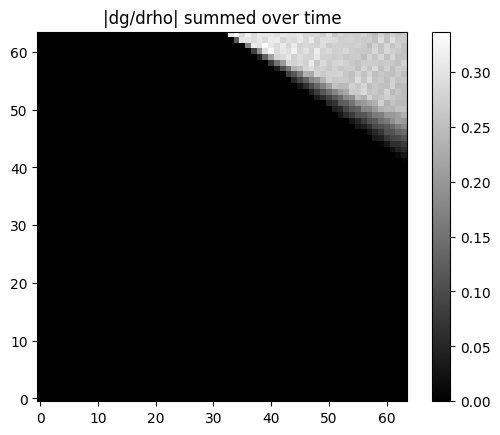

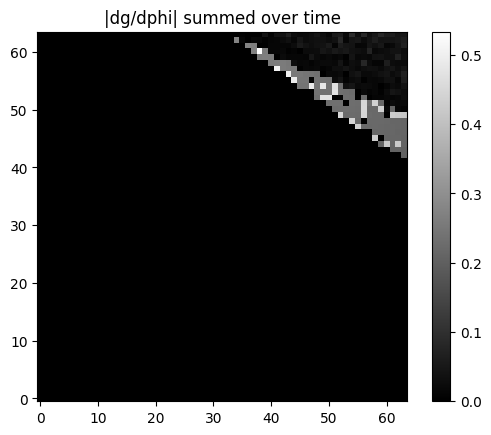

In [41]:
plt.figure()
plt.imshow(range_image, cmap="gray", origin="lower")
plt.title("|dg/drho| summed over time")
plt.colorbar()

plt.figure()
plt.imshow(angle_image, cmap="gray", origin="lower")
plt.title("|dg/dphi| summed over time")
plt.colorbar()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


nominal position [m]: (np.float64(-1.7320508075688774), np.float64(0.9999999999999999))
95% semi-axes [m]: (np.float64(0.16951708124057874), np.float64(4.5053320137677426e-05))
Sigma_xy:
[[0.00119904 0.0020768 ]
 [0.0020768  0.00359712]]


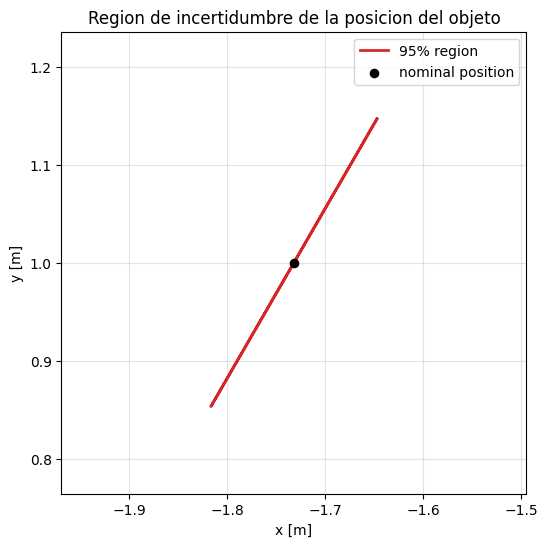

In [42]:
from scipy.stats import chi2

confidence = 0.95

x0 = rho0 * np.cos(phi0)
y0 = rho0 * np.sin(phi0)

A = np.array([
    [np.cos(phi0), -rho0 * np.sin(phi0)],
    [np.sin(phi0),  rho0 * np.cos(phi0)],
])
Sigma_xy = A @ CRB @ A.T

eigvals_xy, eigvecs_xy = np.linalg.eigh(Sigma_xy)
order = np.argsort(eigvals_xy)[::-1]
eigvals_xy = eigvals_xy[order]
eigvecs_xy = eigvecs_xy[:, order]

scale = np.sqrt(chi2.ppf(confidence, df=2))
theta = np.linspace(0, 2 * np.pi, 400)
unit_circle = np.vstack([np.cos(theta), np.sin(theta)])
ellipse_xy = np.array([x0, y0])[:, None] + eigvecs_xy @ (scale * np.sqrt(eigvals_xy)[:, None] * unit_circle)

major_axis = scale * np.sqrt(eigvals_xy[0])
minor_axis = scale * np.sqrt(eigvals_xy[1])
pad = 1.4 * major_axis

plt.figure(figsize=(6, 6))
plt.plot(ellipse_xy[0], ellipse_xy[1], color="tab:red", linewidth=2, label=f"{confidence:.0%} region")
plt.scatter([x0], [y0], color="black", s=35, zorder=3, label="nominal position")
plt.axis("equal")
plt.xlim(x0 - pad, x0 + pad)
plt.ylim(y0 - pad, y0 + pad)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Region de incertidumbre de la posicion del objeto")
plt.grid(True, alpha=0.35)
plt.legend()

print("nominal position [m]:", (x0, y0))
print(f"{confidence:.0%} semi-axes [m]:", (major_axis, minor_axis))
print("Sigma_xy:")
print(Sigma_xy)
